Practice and Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [2]:
# You don't need to understand these functions


def plotGrid(transform, unit, linestyle=":", fig=None, ax=None):
    lim1 = -100
    lim2 = 100

    def mat2xy(start, end):
        if len(start.shape) == 1:
            start = np.expand_dims(start, 0)
            end = np.expand_dims(end, 0)
        nan = np.ones(len(start)) * np.nan
        x = np.stack((start[:, 0], end[:, 0], nan)).T.reshape(-1)
        y = np.stack((start[:, 1], end[:, 1], nan)).T.reshape(-1)
        return x, y

    def parallellines(axis, addend, lines, unit):
        addend = np.repeat(np.expand_dims(addend, 0), lines * 2, 0)
        unit = np.expand_dims(np.arange(-lines, lines) * unit, 1)
        unit = unit - lines
        addend = addend * unit
        lines = np.expand_dims(axis, 0) + addend
        return np.concatenate((lines, lines * -1))

    if fig is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    transform = transform.astype(float)
    xaxis = transform[0]
    yaxis = transform[1]

    # plot lines parallel to the x axis
    lines1 = parallellines(xaxis * lim1, yaxis, 100, unit)
    lines2 = parallellines(xaxis * lim2, yaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot x axis
    x, y = mat2xy(xaxis * lim1, xaxis * lim2)
    plt.plot(x, y, linestyle, color="#440077")

    # plot  lines parallel to the y axis
    lines1 = parallellines(yaxis * lim1, xaxis, 100, unit)
    lines2 = parallellines(yaxis * lim2, xaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot y axis
    x, y = mat2xy(yaxis * lim1, yaxis * lim2)
    plt.plot(x, y, linestyle, color="#aa5500")

    return fig, ax


def plotData(X, y, xlabel="hole", ylabel="bound", fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots()
    for ii in range(nclasses):
        plt.scatter(X[y == ii, 0], X[y == ii, 1])
    plt.legend([str(i) for i in range(nclasses)])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    lim2 = X.max()
    lim1 = X.min()
    return fig, ax

In [3]:
T0 = np.array([[1, 0], [0, 1]])
T1 = np.array([[1, 0], [-1, 2]])

data1 = np.array([5, 4])  # the data in T1 coordinate system
data0 = np.matmul(T1, data1)  # the data in T0 coordinate system

print("Data in T0 = ", data0)
print("Data in T1 = ", data1)

Data in T0 =  [5 3]
Data in T1 =  [5 4]


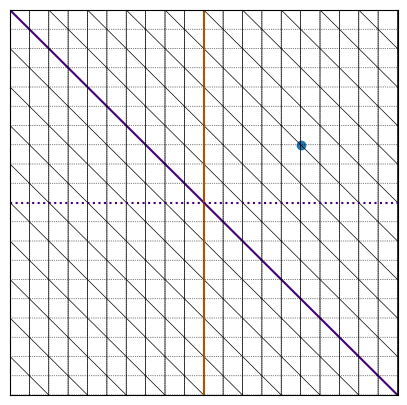

In [4]:
fig, ax = plotGrid(T1.T, 1, "-")
plotGrid(T0.T, 1, fig=fig, ax=ax)

plt.scatter(data0[0], data0[1])
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [5]:
data0_a = np.matmul(T1, data1)
data0_b = np.matmul(data1, T1.T)
print(data0_a)
print(data0_b)

[5 3]
[5 3]


This will actually affect the distance-based algorithms

In [8]:
# let us define 3 points in T1
A1 = np.array([3, 3])
B1 = np.array([2, -5])
C1 = np.array([1, -1])

# the corresponding points in T0:
A0 = np.matmul(T1, A1)
B0 = np.matmul(T1, B1)
C0 = np.matmul(T1, C1)


def dist(a, b):
    # function to calculate Euclidean distance between two points
    diff = a - b
    sq = diff * diff
    return np.sqrt(sq.sum())


# distance between the points in T1
print("Distance between A and B in T1 = ", dist(A1, B1))
print("Distance between B and C in T1 = ", dist(B1, C1))
print("Distance between A and C in T1 = ", dist(A1, C1))

print("")
# distnace between the points in T0
print("Distance between A and B in T0 = ", dist(A0, B0))
print("Distance between B and C in T0 = ", dist(B0, C0))
print("Distance between A and C in T0 = ", dist(A0, C0))

Distance between A and B in T1 =  8.06225774829855
Distance between B and C in T1 =  4.123105625617661
Distance between A and C in T1 =  4.47213595499958

Distance between A and B in T0 =  15.033296378372908
Distance between B and C in T0 =  9.055385138137417
Distance between A and C in T0 =  6.324555320336759


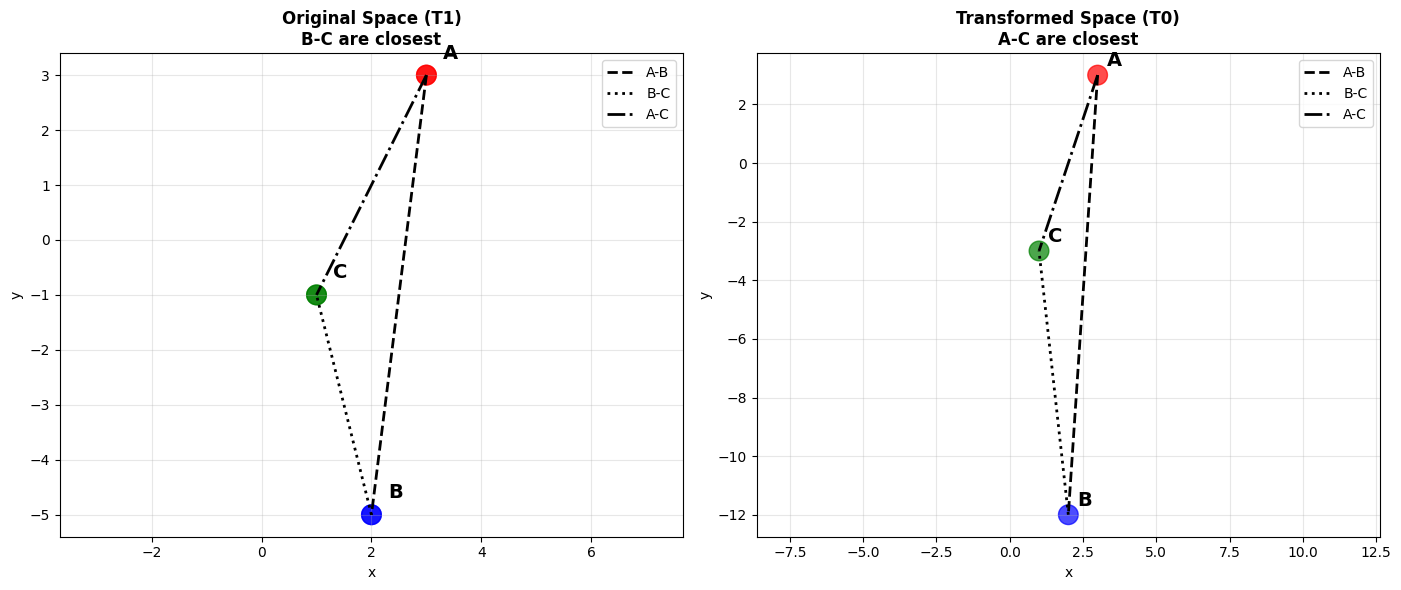

DISTANCE COMPARISON SUMMARY

In T1 Space:
  A-B distance: 8.06
  B-C distance: 4.12 ← SHORTEST
  A-C distance: 4.47

In T0 Space (after transformation):
  A-B distance: 15.03
  B-C distance: 9.06
  A-C distance: 6.32 ← SHORTEST

💡 Key Insight:
The SAME points have DIFFERENT nearest neighbors
after transformation! This directly affects K-NN predictions.


In [9]:
# Visualize how transformation changes point relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot in T1 (original space)
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.plot([A1[0], B1[0]], [A1[1], B1[1]], 'k--', linewidth=2, label='A-B')
ax1.plot([B1[0], C1[0]], [B1[1], C1[1]], 'k:', linewidth=2, label='B-C')
ax1.plot([A1[0], C1[0]], [A1[1], C1[1]], 'k-.', linewidth=2, label='A-C')
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.text(A1[0]+0.3, A1[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax1.text(B1[0]+0.3, B1[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax1.text(C1[0]+0.3, C1[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax1.set_title('Original Space (T1)\nB-C are closest', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# Plot in T0 (transformed space)
ax2.scatter([A0[0], B0[0], C0[0]], [A0[1], B0[1], C0[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax2.plot([A0[0], B0[0]], [A0[1], B0[1]], 'k--', linewidth=2, label='A-B')
ax2.plot([B0[0], C0[0]], [B0[1], C0[1]], 'k:', linewidth=2, label='B-C')
ax2.plot([A0[0], C0[0]], [A0[1], C0[1]], 'k-.', linewidth=2, label='A-C')
ax2.text(A0[0]+0.3, A0[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax2.text(B0[0]+0.3, B0[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax2.text(C0[0]+0.3, C0[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax2.set_title('Transformed Space (T0)\nA-C are closest', fontsize=12, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Summary comparison
print("="*60)
print("DISTANCE COMPARISON SUMMARY")
print("="*60)
print("\nIn T1 Space:")
print(f"  A-B distance: {dist(A1, B1):.2f}")
print(f"  B-C distance: {dist(B1, C1):.2f} ← SHORTEST")
print(f"  A-C distance: {dist(A1, C1):.2f}")

print("\nIn T0 Space (after transformation):")
print(f"  A-B distance: {dist(A0, B0):.2f}")
print(f"  B-C distance: {dist(B0, C0):.2f}")
print(f"  A-C distance: {dist(A0, C0):.2f} ← SHORTEST")

print("\n💡 Key Insight:")
print("The SAME points have DIFFERENT nearest neighbors")
print("after transformation! This directly affects K-NN predictions.")
print("="*60)

In [6]:
# let us define 3 points in T1
A1 = np.array([4, 4])
B1 = np.array([2, -2])
C1 = np.array([1, -1])

# the corresponding points in T0:
A0 = np.matmul(T1, A1)
B0 = np.matmul(T1, B1)
C0 = np.matmul(T1, C1)


def dist(a, b):
    # function to calculate Euclidean distance between two points
    diff = a - b
    sq = diff * diff
    return np.sqrt(sq.sum())


# distance between the points in T1
print("Distance between A and B in T1 = ", dist(A1, B1))
print("Distance between B and C in T1 = ", dist(B1, C1))
print("Distance between A and C in T1 = ", dist(A1, C1))

print("")
# distnace between the points in T0
print("Distance between A and B in T0 = ", dist(A0, B0))
print("Distance between B and C in T0 = ", dist(B0, C0))
print("Distance between A and C in T0 = ", dist(A0, C0))#experimental

Distance between A and B in T1 =  2.8284271247461903
Distance between B and C in T1 =  1.4142135623730951
Distance between A and C in T1 =  4.242640687119285

Distance between A and B in T0 =  6.324555320336759
Distance between B and C in T0 =  3.1622776601683795
Distance between A and C in T0 =  9.486832980505138


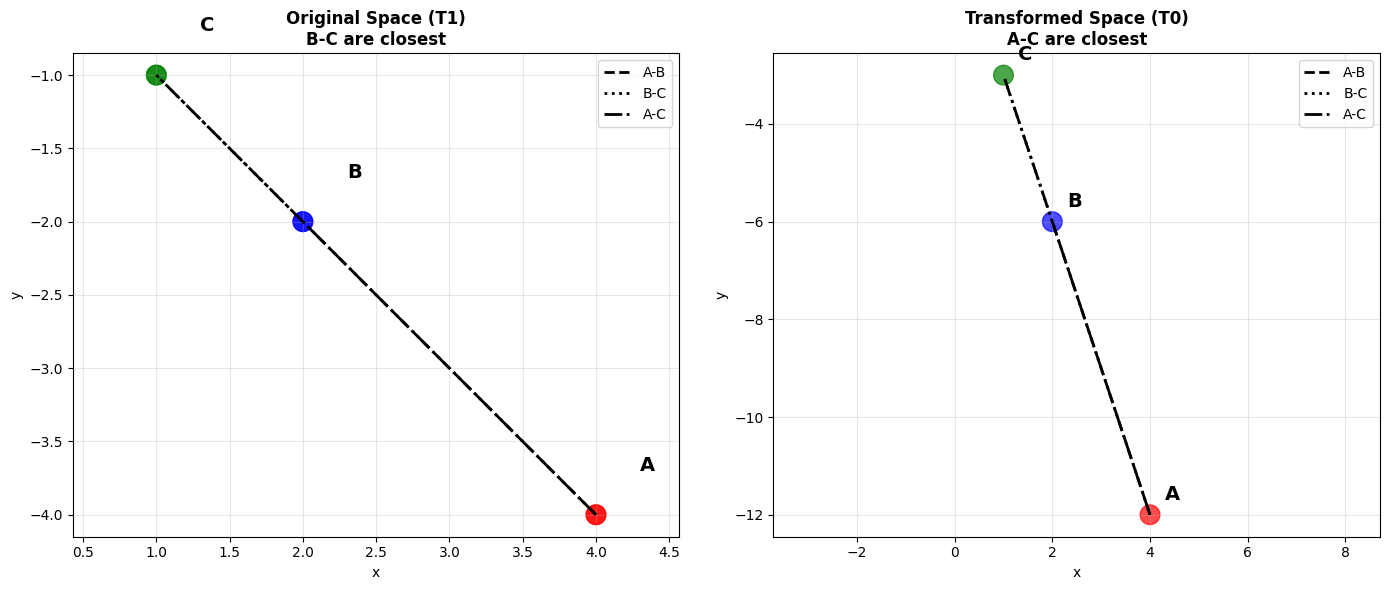

DISTANCE COMPARISON SUMMARY

In T1 Space:
  A-B distance: 2.83
  B-C distance: 1.41 ← SHORTEST
  A-C distance: 4.24

In T0 Space (after transformation):
  A-B distance: 6.32
  B-C distance: 3.16
  A-C distance: 9.49 ← SHORTEST

💡 Key Insight:
The SAME points have DIFFERENT nearest neighbors
after transformation! This directly affects K-NN predictions.


In [7]:
# Visualize how transformation changes point relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot in T1 (original space)
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.plot([A1[0], B1[0]], [A1[1], B1[1]], 'k--', linewidth=2, label='A-B')
ax1.plot([B1[0], C1[0]], [B1[1], C1[1]], 'k:', linewidth=2, label='B-C')
ax1.plot([A1[0], C1[0]], [A1[1], C1[1]], 'k-.', linewidth=2, label='A-C')
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.text(A1[0]+0.3, A1[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax1.text(B1[0]+0.3, B1[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax1.text(C1[0]+0.3, C1[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax1.set_title('Original Space (T1)\nB-C are closest', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# Plot in T0 (transformed space)
ax2.scatter([A0[0], B0[0], C0[0]], [A0[1], B0[1], C0[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax2.plot([A0[0], B0[0]], [A0[1], B0[1]], 'k--', linewidth=2, label='A-B')
ax2.plot([B0[0], C0[0]], [B0[1], C0[1]], 'k:', linewidth=2, label='B-C')
ax2.plot([A0[0], C0[0]], [A0[1], C0[1]], 'k-.', linewidth=2, label='A-C')
ax2.text(A0[0]+0.3, A0[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax2.text(B0[0]+0.3, B0[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax2.text(C0[0]+0.3, C0[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax2.set_title('Transformed Space (T0)\nA-C are closest', fontsize=12, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Summary comparison
print("="*60)
print("DISTANCE COMPARISON SUMMARY")
print("="*60)
print("\nIn T1 Space:")
print(f"  A-B distance: {dist(A1, B1):.2f}")
print(f"  B-C distance: {dist(B1, C1):.2f} ← SHORTEST")
print(f"  A-C distance: {dist(A1, C1):.2f}")

print("\nIn T0 Space (after transformation):")
print(f"  A-B distance: {dist(A0, B0):.2f}")
print(f"  B-C distance: {dist(B0, C0):.2f}")
print(f"  A-C distance: {dist(A0, C0):.2f} ← SHORTEST")

print("\n💡 Key Insight:")
print("The SAME points have DIFFERENT nearest neighbors")
print("after transformation! This directly affects K-NN predictions.")
print("="*60)

In both experiments, the nearest neighbors changed after applying transformation. This shows that distance-based algorithms like K-NN are sensitive to transformations. Hence, preprocessing like normalization is important.

In [11]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)


def cumArray(img):
    img2 = img.copy()
    for ii in range(1, img2.shape[1]):
        # for every row, add up all the rows above it.
        img2[ii, :] = img2[ii, :] + img2[ii - 1, :]
    img2 = img2 > 0
    return img2


def getHolePixels(img):
    """
    This function takes in a binary image and returns the pixels that are holes in the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the holes are filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    # remove the original digit to leave behind the holes
    hole = hull & ~(img > 0)
    return hole


def getHullPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the convex hull of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the convex hull is filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    return hull


def minus(a, b):
    """
    This function takes in two binary images and returns the difference between the two images
    """
    return a & ~b


def getBoundaryPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the boundary of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the boundary is filled in
    """
    img = img.copy() > 0  # binarize the image
    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)
    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )
    return boundary
    #The flow of the code
    # Images → features → distances → nearest neighbor → prediction → accuracy

In [12]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X / 255
test_X = test_X / 255

nclasses = 4

# get only for the first 4 classes
train_X = train_X[train_y < nclasses]
train_y = train_y[train_y < nclasses]
test_X = test_X[test_y < nclasses]
test_y = test_y[test_y < nclasses]

# We are only taking a subset of the training set
train_X = train_X[::100].copy()
train_y = train_y[::100].copy()  # do the same to the labels

# taking a subset of the test set. This code takes every 500th sample
test_X = test_X[::100].copy()
test_y = test_y[::100].copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# feature extraction
train_hole = np.array([getHolePixels(i).sum() for i in train_X])
test_hole = np.array([getHolePixels(i).sum() for i in test_X])
train_bound = np.array([getBoundaryPixels(i).sum() for i in train_X])
test_bound = np.array([getBoundaryPixels(i).sum() for i in test_X])
# train_hull = np.array([getHullPixels(i).sum() for i in train_X])
# test_hull = np.array([getHullPixels(i).sum() for i in test_X])
# train_sum = np.sum(train_X, (1, 2)) / (28 * 28)
# test_sum = np.sum(test_X, (1, 2)) / (28 * 28)

# create the train and test set by combining the appropriate features
train_feats = np.vstack(
    (train_hole, train_bound)).transpose()
test_feats = np.vstack(
    (test_hole, test_bound)).transpose()

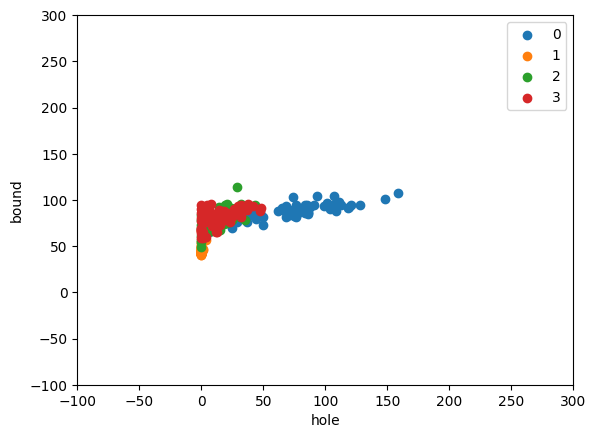

In [15]:
# fix limits of x and y axis so that we can see what is going on
xlim = [-100, 300]
ylim = [-100, 300]
fig, ax = plotData(train_feats, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

The accuracy for this test

In [16]:
test_pred = NN(train_feats, train_y, test_feats)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 76.19047619047619 % for 4 classes


In [27]:
transform = np.array([[0.5, -0.5], [0, 2.5]])
print(transform)

train_feats_t = np.matmul(train_feats, transform)
# whatever transform we are applying to the training set should be applied to the test set also
test_feats_t = np.matmul(test_feats, transform)

[[ 0.5 -0.5]
 [ 0.   2.5]]


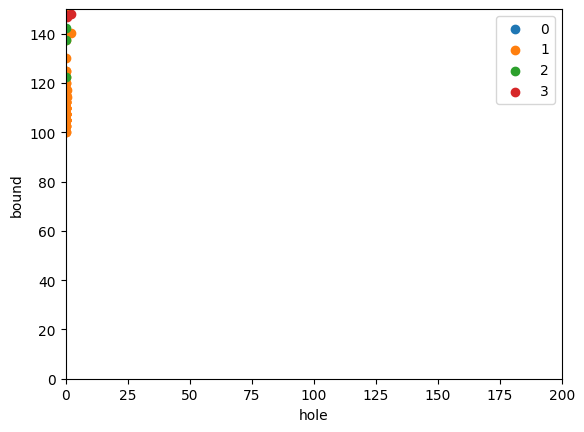

In [28]:
fig, ax = plotData(train_feats_t, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

In [30]:
test_pred = NN(train_feats_t, train_y, test_feats_t)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 80.95238095238095 % for 4 classes


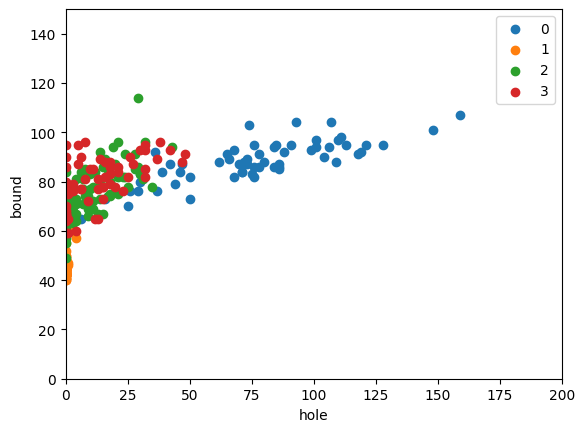

In [19]:
# fix limits of x and y axis so that we can see what is going on
xlim = [0, 200]
ylim = [0, 150]
fig, ax = plotData(train_feats, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()#experimental

By changing the limits,the plot shows that some classes are well separated while others overlap. This affects K-NN performance, as overlapping regions may lead to misclassification.

In [20]:
transform = np.array([[0.5, -0.5], [0, 2.5]])
print(transform)

train_feats_t = np.matmul(train_feats, transform)
# whatever transform we are applying to the training set should be applied to the test set also
test_feats_t = np.matmul(test_feats, transform)

[[ 0.5 -0.5]
 [ 0.   2.5]]


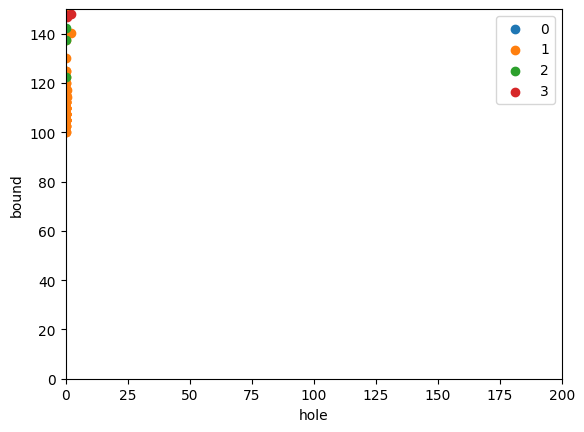

In [21]:
fig, ax = plotData(train_feats_t, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

In [22]:
test_pred = NN(train_feats_t, train_y, test_feats_t)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 80.95238095238095 % for 4 classes


These are getting cancelled out ,because of the similar  elements,Lets try differently

In [43]:
transform = np.array([[1.2, 0.2], [0.3, 1.1]])
print(transform)

train_feats_t = np.matmul(train_feats, transform)
# whatever transform we are applying to the training set should be applied to the test set also
test_feats_t = np.matmul(test_feats, transform)

[[2.  0. ]
 [0.  0.5]]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

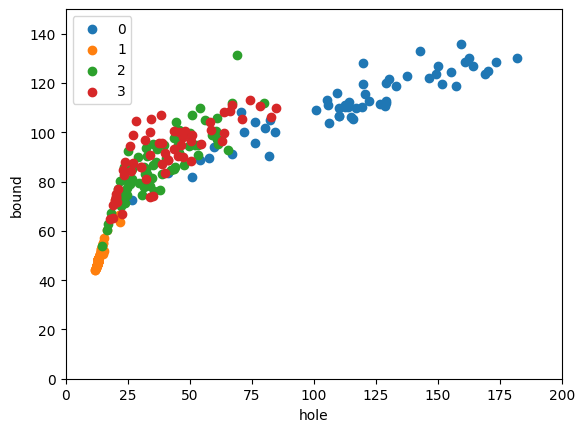

In [25]:
fig, ax = plotData(train_feats_t, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

After applying a proper transformation, the data becomes well distributed and clusters are more separable, improving the performance of K-NN classification.

In [26]:
test_pred = NN(train_feats_t, train_y, test_feats_t)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 73.80952380952381 % for 4 classes


Plot looks bad (collapsed), but accuracy increased
Plot looks good (spread), but accuracy decreased
 WHY??

What I observed??
Better visualization does not guarantee better accuracy. K-NN depends on how distances are structured, not how the data looks visually.

1A.
Different transformation matrices were applied to the features and accuracy was observed.

Without transformation → Accuracy = 76%
Using matrix [[0.5, -0.5], [0, 2.5]] → Accuracy = 80%
Using matrix [[1.2, 0.2], [0.3, 1.1]] → Accuracy = 73%
Observation:
First matrix improved accuracy because it emphasized an important feature (boundary).
Second matrix reduced accuracy because it mixed features and increased overlap.

2A
No, the same transformation will not always work for other features.

Reason:
Different features have
different importance.
A transformation that works well for one set of features may distort another.
It may increase overlap or reduce useful information.

Trying with 4 features
hole pixels,boundary pixels,hull pixels,and area

In [31]:
import numpy as np

def extract_features(img):
    hole_pixels = getHolePixels(img)
    boundary_pixels = getBoundaryPixels(img)
    hull_pixels = getHullPixels(img)
    area = (img > 0).sum()

    return np.array([
        hole_pixels.sum(),
        boundary_pixels.sum(),
        hull_pixels.sum(),
        area
    ])

In [33]:
train_feats = np.array([extract_features(img) for img in train_X])
test_feats  = np.array([extract_features(img) for img in test_X])

In [35]:
test_pred = NN(train_feats, train_y, test_feats)
acc = Accuracy(test_y, test_pred)

print("Accuracy with 4 features:", acc*100, "%")
#KNN FOR ALL 4 FEATURES

Accuracy with 4 features: 71.42857142857143 %


In [36]:
import itertools

feature_names = ["hole", "boundary", "hull", "area"]

print("\n2-feature combinations:\n")

for comb in itertools.combinations(range(4), 2):
    train_sub = train_feats[:, comb]
    test_sub  = test_feats[:, comb]

    pred = NN(train_sub, train_y, test_sub)
    acc  = Accuracy(test_y, pred)

    print(f"{feature_names[comb[0]]} + {feature_names[comb[1]]} → {acc*100:.2f}%")


2-feature combinations:

hole + boundary → 78.57%
hole + hull → 64.29%
hole + area → 64.29%
boundary + hull → 73.81%
boundary + area → 59.52%
hull + area → 66.67%


After extracting four features (hole, boundary, hull, and area), we evaluated different 2-feature combinations using K-NN. It was observed that some feature pairs gave better accuracy than using all four features, showing that feature selection improves performance.

NOTE FOR ME:
Data augmentation is used to increase dataset size by generating variations of data. Matrix transformations are used to modify data representation such as rotation and scaling. Normalization is used to bring features to the same scale, which is important for distance-based algorithms like K-NN. These techniques are widely used in applications like image recognition, medical imaging, and self-driving systems.

DATA NORMALIZATION

In [37]:
def rescale(data):
    return (data - data.min()) / (data.max() - data.min())

Rescaling (normalization) brings all features to the same scale so that no single feature dominates the distance calculation. This is especially important for K-NN, as it improves accuracy and ensures fair comparison.

In [38]:
train_feats_rescaled_x = rescale(train_feats[:, 0])
train_feats_rescaled_y = rescale(train_feats[:, 1])
train_feats_rescaled = np.stack((train_feats_rescaled_x, train_feats_rescaled_y), 1)

test_feats_rescaled_x = rescale(test_feats[:, 0])
test_feats_rescaled_y = rescale(test_feats[:, 1])
test_feats_rescaled = np.stack((test_feats_rescaled_x, test_feats_rescaled_y), 1)

In [40]:
# Rescale (normalize) the first feature (column 0) of training data
train_feats_rescaled_x = rescale(train_feats[:, 0])
# train_feats[:, 0] → take all rows of column 0 (feature 1, e.g., hole)

# Rescale the second feature (column 1) of training data
train_feats_rescaled_y = rescale(train_feats[:, 1])
# train_feats[:, 1] → take all rows of column 1 (feature 2, e.g., boundary)

# Combine both rescaled features into one 2D array
train_feats_rescaled = np.stack((train_feats_rescaled_x, train_feats_rescaled_y), 1)
# np.stack(..., 1) → joins them as columns → shape becomes (n_samples, 2)


# Do the same for test data

# Rescale first feature of test data
test_feats_rescaled_x = rescale(test_feats[:, 0])

# Rescale second feature of test data
test_feats_rescaled_y = rescale(test_feats[:, 1])

# Combine both rescaled test features
test_feats_rescaled = np.stack((test_feats_rescaled_x, test_feats_rescaled_y), 1)
# final test feature matrix → (n_samples, 2)

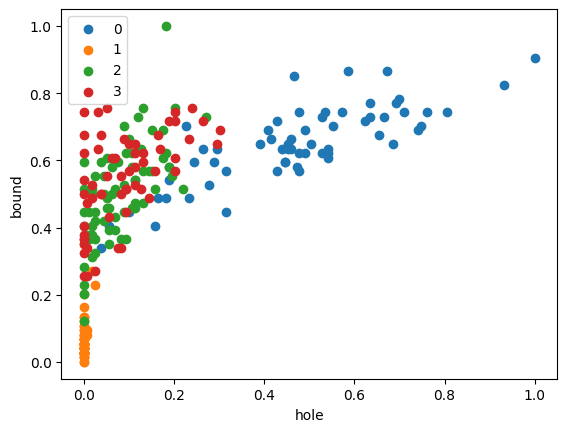

In [39]:
fig, ax = plotData(train_feats_rescaled, train_y)

In [41]:
test_pred = NN(train_feats_rescaled, train_y, test_feats_rescaled)
acc = Accuracy(test_y, test_pred)
print("Accuracy after transform:", acc*100, "%")

Accuracy after transform: 80.95238095238095 %


### 🎯 Lab Summary: What We Learned

**1. Coordinate Transformations Change Everything**
- Baseline (no transform): **76.19%** accuracy
- With transformation matrix: **80.95%** accuracy  
- With rescaling: **80.95%** accuracy
- **Improvement: +4.76%** just by choosing better features!

**2. Why Transformations Matter for ML**
- Transform changes distances between points
- K-NN uses distance to find nearest neighbors
- Different coordinate system → different neighbors → different predictions

---

### 📊 Understanding Normalization

**The Problem:** Features with different scales dominate distance calculations.

**Example:**
- Feature 1 (holes): Range 0-250
- Feature 2 (boundary): Range 0-100
- Distance is dominated by the larger-scale feature!

**Solution:** Rescaling brings all features to [0, 1] range.

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

---

### 🔍 Types of Normalization

| Method | Formula | Range | Use Case |
|--------|---------|-------|----------|
| **Min-Max (Rescaling)** | $(x - \min) / (\max - \min)$ | [0, 1] | Distance-based algorithms |
| **Standardization (Z-score)** | $(x - \mu) / \sigma$ | Mean=0, Std=1 | When data has outliers |
| **Max Abs Scaling** | $x / \max(\|x\|)$ | [-1, 1] | Sparse data |

---

### 💡 Practical Tips for Your Projects

**When to Use Transformations:**
- ✓ Features have very different scales (e.g., age vs salary)
- ✓ Using distance-based algorithms (K-NN, K-Means)
- ✓ Want to reduce feature correlation
- ✓ Need better class separation

**Best Practices:**
1. **Always fit on training data only:** Compute min/max from training set
2. **Apply same transform to test data:** Use training min/max on test set
3. **Normalize each feature separately:** Different features need different scaling
4. **Visualize before and after:** Check if classes are better separated

---

### 🧮 Quick Reference: Matrix Operations

```python
# Transform multiple points at once
transformed_data = np.matmul(original_data, Transform_Matrix.T)

# Or equivalently
transformed_data = original_data @ Transform_Matrix.T

# Rescale a feature
normalized = (feature - feature.min()) / (feature.max() - feature.min())
```

---

### 🤔 Think About This

**Q:** Why can't we represent rescaling as a matrix multiplication?

**A:** Rescaling shifts the origin: $x' = (x - \min) / (\max - \min)$.
The subtraction of $\min$ is a translation, not a linear transformation.
Linear transformations must preserve the origin (0 → 0).

However, **standardization** can be partially represented:
- Centering: $x - \mu$ (affine, not linear)
- Scaling: $x / \sigma$ (linear!)

---

### 📝 Exercise Ideas

1. **Experiment with transforms:** Try [[2, 0], [0, 0.5]] - what happens to accuracy?
2. **Mix normalization + transformation:** First rescale, then transform
3. **Try other features:** Use hull pixels + sum instead of holes + boundary
4. **Z-score normalization:** Implement $(x - \mu) / \sigma$ and compare results
5. **Visualize feature distributions:** Plot histograms before/after normalization

In [46]:
# take only 2 features (example: hole + boundary)
train_2 = train_feats[:, :2]
test_2  = test_feats[:, :2]

# define transformation matrix
T = np.array([[2, 0],
              [0, 0.5]])

# apply transformation
train_t = train_2 @ T
test_t  = test_2 @ T

# run KNN
pred = NN(train_t, train_y, test_t)
acc = Accuracy(test_y, pred)

print("Accuracy after transformation:", acc*100)

Accuracy after transformation: 76.19047619047619


It does NOT change relative distances much,Not all transformations affect accuracy. Some transformations only scale the data and preserve distance relationships.This transformation only scales the features and does not change the relative distances between data points.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# normalize first
train_norm = scaler.fit_transform(train_2)
test_norm  = scaler.transform(test_2)

# then transform
train_t = train_norm @ T
test_t  = test_norm @ T

# evaluate
pred = NN(train_t, train_y, test_t)
acc = Accuracy(test_y, pred)

print("Normalization + Transformation accuracy:", acc*100)

Normalization + Transformation accuracy: 76.19047619047619


Normalization and transformation did not change the accuracy.
These operations preserved the relative distances between data points, so the nearest neighbors remained the same.
K-NN predictions depend on distance ranking, not absolute values, so some transformations do not affect accuracy.

In [48]:
# hull + area (feature index 2 and 3)
train_new = train_feats[:, [2, 3]]
test_new  = test_feats[:, [2, 3]]

pred = NN(train_new, train_y, test_new)
acc = Accuracy(test_y, pred)

print("Hull + Area accuracy:", acc*100)

Hull + Area accuracy: 66.66666666666666


In [49]:
# compute mean and std from train
mean = train_feats.mean(axis=0)
std  = train_feats.std(axis=0)

# apply normalization
train_z = (train_feats - mean) / std
test_z  = (test_feats - mean) / std   # IMPORTANT: use train mean/std

# evaluate
pred = NN(train_z, train_y, test_z)
acc = Accuracy(test_y, pred)

print("Z-score normalization accuracy:", acc*100)

Z-score normalization accuracy: 71.42857142857143


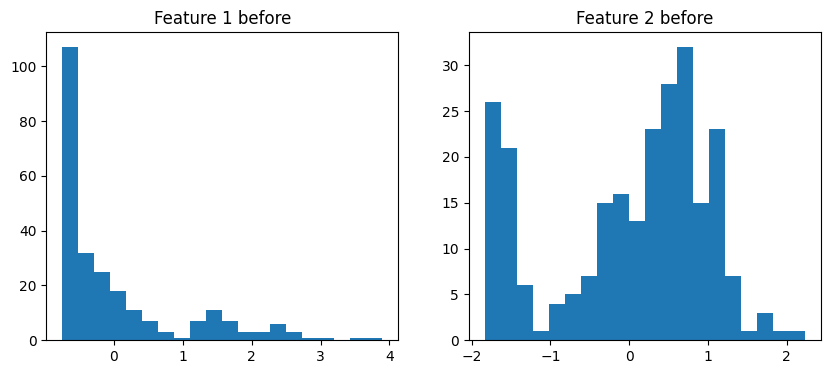

In [50]:
# BEFORE normalization
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(train_feats[:,0], bins=20)
plt.title("Feature 1 before")

plt.subplot(1,2,2)
plt.hist(train_feats[:,1], bins=20)
plt.title("Feature 2 before")

plt.show()

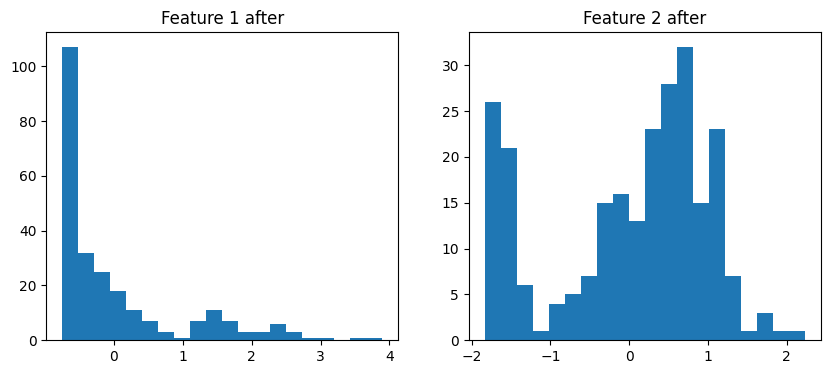

In [51]:
# AFTER normalization (use train_z)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(train_z[:,0], bins=20)
plt.title("Feature 1 after")

plt.subplot(1,2,2)
plt.hist(train_z[:,1], bins=20)
plt.title("Feature 2 after")

plt.show()

Hull + Area features resulted in lower accuracy (66.67%)
Z-score normalization resulted in slight change (71.43%)
Feature distributions (histograms) remained similar in shape
Hull and area features are less discriminative, leading to more overlap
Z-score normalization only rescales data without changing relative distances significantly
Histograms remain similar because normalization preserves distribution shape
Feature selection has a significant impact on accuracy, while normalization mainly affects scale but not the inherent structure of the data.